# Model comparison — trend classification across horizons

Compares the trend classifiers on the **OFI** feature stream over the label
horizons **k ∈ {10, 20, 50, 100}**:

| tag | class | family |
|-----|-------|--------|
| `dla + ofi`            | `DLA`            | attention encoder–decoder |
| `tlob + ofi`           | `TLOB`           | temporal/spatial transformer |
| `binctabl + ofi`       | `BINCTABL`       | bilinear + BiN |
| `ctabl + ofi`          | `CTABL`          | bilinear temporal attention |
| `deeplob + ofi`        | `DeepLOB`        | CNN + inception + LSTM |
| `jumpgatelob + ofi`    | `JumpGateLOB`    | jump-diffusion score matching + noise-consistent classifier |
| `alphastablelob + ofi` | `AlphaStableLOB` | α-stable joint diffusion-classifier |

Every model exposes `predict(batch, device) → (B, 3) logits`, so the metrics
(accuracy, macro-F1, per-class F1, confusion) are computed identically.

**Sections**
1. Setup & checkpoint registry (auto-discovered, editable)
2. Load models + build the shared per-horizon test set (incl. per-window realized trend)
3. Overall metrics (accuracy / macro-F1 / per-class F1) across horizons
4. Confusion matrices
5. Metric-vs-horizon curves
6. Extreme conditions (jumps) — performance on turbulent windows
7. Financial / trading metrics — MCC/κ, signal quality, mid-price prediction
   overlay, calibration & confidence gating
8. Final model comparison table

> Run from the **Penny repo root** so the `data/` cache and `checkpoints/`
> relative paths resolve.


## 1. Setup


In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import (
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
)
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


# --- locate the repo root and chdir into it -----------------------------------
# Jupyter kernels default their cwd to wherever the server was launched (often
# the notebook's own directory, e.g. `notebooks/`), NOT the repo root. Config
# files store paths like "data/resampled/nobitex" that `build_cache` resolves
# against the *live process cwd* — so if we only add `src/` to sys.path without
# also chdir'ing, imports succeed but data loading fails with a confusing
# "parquet not found" error. Walk up from cwd to find `pyproject.toml` and
# chdir there so every relative path in every config resolves the same way
# regardless of how this notebook was launched.
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").is_dir():
            return p
    raise RuntimeError(
        f"could not find the Penny repo root (pyproject.toml + src/) above {start}"
    )


REPO = _find_repo_root(Path.cwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))
print("repo root:", REPO)

from crypto.dataset import build_datasets  # noqa: E402
from crypto.features import extract_features, n_features  # noqa: E402
from crypto.labels import compute_trend_series  # noqa: E402
from crypto.loader import build_cache  # noqa: E402
from models.alphastablelob import AlphaStableLOB  # noqa: E402
from models.ctabl import CTABL  # noqa: E402
from models.deeplob import DeepLOB  # noqa: E402
from models.jumpgatelob import JumpGateLOB  # noqa: E402
from models.tlob import TLOB  # noqa: E402

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

repo root: /Users/arshia/Projects/Personal/Penny
device: cpu


## 2. Registry & checkpoints

`MODELS` maps each tag to its class. `HORIZONS` are the label-`k` values.

`CHECKPOINTS[model][k]` is a path to a checkpoint **directory** (containing
`best.pt`) or the `best.pt` file itself. It is auto-populated by scanning
`CHECKPOINT_ROOT` and reading each run's sibling `config.json` for
`(feature_mode, label_k, symbol)` — the newest run wins. **Edit the printed dict
to point at the exact checkpoints you want.**

In [2]:
FEATURE_MODE = "ofi"
SYMBOL = "BTCIRT"
HORIZONS = [10, 20, 50, 100]
BATCH = 256

# tag -> (class, checkpoint-dir prefix written by the train scripts)
MODELS = {
    # "dla": (DLA, "dla_"),
    # "axial":       (AxialLOB,    "axiallob_"),
    "tlob": (TLOB, "tlob_"),
    # "binctabl": (BINCTABL, "binctabl_"),
    "ctabl": (CTABL, "ctabl_"),
    "deeplob": (DeepLOB, "deeplob_"),
    "jumpgatelob": (JumpGateLOB, "jumpgatelob_"),
    "alphastablelob_1.5": (AlphaStableLOB, "alphastablelob_joint_a15"),
    "alphastablelob_1.7": (AlphaStableLOB, "alphastablelob_joint_a17"),
}
LABELS = ["down", "stationary", "up"]
DISPLAY = {m: f"{m} + {FEATURE_MODE}" for m in MODELS}

# where to scan for runs (change if your checkpoints live elsewhere)
CHECKPOINT_ROOT = REPO / "checkpoints" / "nobitex" / SYMBOL

# JSON config used only to BUILD the shared test set for each horizon.
# Any model's ofi config for that k works (identical data params); jumpgatelob
# ships one per horizon.
DATA_CONFIG = "configs/crypto/nobitex/jumpgatelob/btcirt_{fm}_k{k}.json"


def _run_config(run_dir: Path) -> dict | None:
    """Read a run's sidecar config.json (falls back to best.pt if absent)."""
    cj = run_dir / "config.json"
    if cj.exists():
        try:
            return json.loads(cj.read_text())
        except Exception:
            pass
    bp = run_dir / "best.pt"
    if bp.exists():
        try:
            return torch.load(bp, map_location="cpu", weights_only=False)["config"]
        except Exception:
            pass
    return None


def discover_checkpoints() -> dict:
    """tag -> {k -> newest matching run dir}, matched on prefix + config."""
    found = {m: {} for m in MODELS}
    if not CHECKPOINT_ROOT.exists():
        print(f"! CHECKPOINT_ROOT does not exist: {CHECKPOINT_ROOT}")
        return found
    for run in sorted(CHECKPOINT_ROOT.iterdir()):  # lexical == chronological
        if not run.is_dir():
            continue
        for tag, (_cls, prefix) in MODELS.items():
            if not run.name.startswith(prefix):
                continue
            cfg = _run_config(run)
            if cfg is None:
                continue
            k = cfg.get("label_k")
            if (
                cfg.get("feature_mode") == FEATURE_MODE
                and cfg.get("symbol") == SYMBOL
                and k in HORIZONS
            ):
                found[tag][k] = str(run)  # newest overwrites
    return found


CHECKPOINTS = discover_checkpoints()
print("Auto-discovered checkpoints (edit below if needed):\n")
for m in MODELS:
    row = ", ".join(f"k{k}:{'✓' if k in CHECKPOINTS[m] else '—'}" for k in HORIZONS)
    print(f"  {DISPLAY[m]:<24} {row}")
CHECKPOINTS

Auto-discovered checkpoints (edit below if needed):

  tlob + ofi               k10:✓, k20:✓, k50:✓, k100:✓
  ctabl + ofi              k10:✓, k20:✓, k50:✓, k100:✓
  deeplob + ofi            k10:✓, k20:✓, k50:✓, k100:✓
  jumpgatelob + ofi        k10:✓, k20:✓, k50:✓, k100:✓
  alphastablelob_1.5 + ofi k10:✓, k20:✓, k50:✓, k100:✓
  alphastablelob_1.7 + ofi k10:✓, k20:✓, k50:✓, k100:✓


{'tlob': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/tlob_BTCIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/tlob_BTCIRT_ofi_k100',
  20: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/tlob_BTCIRT_ofi_k20',
  50: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/tlob_BTCIRT_ofi_k50'},
 'ctabl': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/ctabl_BTCIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/ctabl_BTCIRT_ofi_k100',
  20: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/ctabl_BTCIRT_ofi_k20',
  50: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/ctabl_BTCIRT_ofi_k50'},
 'deeplob': {10: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/deeplob_BTCIRT_ofi_k10',
  100: '/Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT/deeplob_BTCIRT_ofi_k100',
  20: '/Users/

## 3. Load models & evaluate

The test set is built **once per horizon** and shared across all models, so
every model is scored on the identical windows and labels. For each window we
also record a **stress score** — the repo's own market-jump measure
(`_data_jump_flag`): the largest 1-step increment of the level-averaged feature,
in realized-volatility units. Higher ⇒ more turbulent input.

In [3]:
def load_ckpt(path: str):
    p = Path(path)
    if p.is_dir():
        p = p / "best.pt"
    return torch.load(p, map_location=DEVICE, weights_only=False)


def build_model(tag: str, ckpt: dict):
    cls, _ = MODELS[tag]
    model = cls(ckpt["config"]).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model


_DS_CACHE: dict[int, tuple] = {}
# META[k] = {"mid", "ts", "centres", "trend", "alpha"} — per-window financial
# ground truth: `centres` indexes each test window's label bin into the full
# `mid`/`ts` series; `trend` is the realized smoothed trend_ratio at that bin
# (the exact quantity the ±alpha label thresholds), used by section 7.
META: dict[int, dict] = {}


def test_set(k: int):
    """(test_ds, y_true, stress) for horizon k — built once, then cached."""
    if k in _DS_CACHE:
        return _DS_CACHE[k]
    cfg_path = REPO / DATA_CONFIG.format(fm=FEATURE_MODE, k=k)
    cfg = json.loads(cfg_path.read_text())
    _, _, test_ds, alpha, meta = build_datasets(cfg)
    loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)
    ys, ss = [], []
    for b in loader:
        x = b["x"].float()  # (B, 1, T, F)
        agg = x.squeeze(1).mean(-1)  # (B, T) level-averaged stream
        dif = agg[:, 1:] - agg[:, :-1]
        rv = dif.std(dim=1).clamp_min(1e-8)
        ss.append((dif.abs().max(dim=1).values / rv).numpy())
        ys.append(b["label"].numpy())
    y_true = np.concatenate(ys)
    stress = np.concatenate(ss)

    # financial ground truth: mid series + realized trend at each window centre
    feat, mid, ts = build_cache(cfg, extract_features, n_features, tag="lob")
    centres = np.asarray(test_ds.starts) + cfg["T_past"] - 1
    trend = compute_trend_series(mid, k)[centres]
    lab_chk = np.where(trend > alpha, 2, np.where(trend < -alpha, 0, 1))
    mism = float((lab_chk != y_true).mean())
    if mism > 1e-3:
        print(f"  ! label/trend mismatch {mism:.2%} — check alpha/config alignment")
    META[k] = {"mid": mid, "ts": ts, "centres": centres, "trend": trend, "alpha": alpha}

    print(
        f"  k={k:<3} test windows={len(y_true):>6}  "
        f"class balance {np.bincount(y_true, minlength=3) / len(y_true)}  "
        f"mean |trend|={np.abs(trend).mean() * 1e4:.2f} bp"
    )
    _DS_CACHE[k] = (test_ds, y_true, stress)
    return _DS_CACHE[k]


@torch.no_grad()
def evaluate(model, test_ds):
    loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)
    yt, yp, pr = [], [], []
    for b in loader:
        logits = model.predict(b, DEVICE)
        pr.append(Fn.softmax(logits, dim=1).cpu().numpy())
        yp.append(logits.argmax(dim=1).cpu().numpy())
        yt.append(b["label"].numpy())
    return np.concatenate(yt), np.concatenate(yp), np.concatenate(pr)

In [4]:
# RESULTS[(tag, k)] = {"y_true", "y_pred", "probs", "stress"}
RESULTS: dict = {}

for k in HORIZONS:
    print(f"horizon k={k}")
    try:
        test_ds, y_true, stress = test_set(k)
    except FileNotFoundError as e:
        print(f"  ! could not build test set for k={k}: {e}")
        print(
            f"    (cwd is {Path.cwd()} — if this looks wrong, re-run the setup "
            f"cell; if the file is genuinely missing, run `uv run dvc pull`)"
        )
        continue
    except Exception as e:
        print(f"  ! could not build test set for k={k}: {e}")
        continue
    for tag in MODELS:
        path = CHECKPOINTS.get(tag, {}).get(k)
        if not path or not Path(path).exists():
            print(f"  {DISPLAY[tag]:<24} — no checkpoint, skipped")
            continue
        ckpt = load_ckpt(path)
        cfg = ckpt["config"]
        if cfg.get("label_k") != k or cfg.get("feature_mode") != FEATURE_MODE:
            print(
                f"  {DISPLAY[tag]:<24} ! config mismatch "
                f"(k={cfg.get('label_k')}, fm={cfg.get('feature_mode')}), skipped"
            )
            continue
        model = build_model(tag, ckpt)
        yt, yp, pr = evaluate(model, test_ds)
        assert np.array_equal(yt, y_true), "window/label misalignment"
        RESULTS[(tag, k)] = {"y_true": yt, "y_pred": yp, "probs": pr, "stress": stress}
        acc = (yt == yp).mean()
        f1 = f1_score(yt, yp, average="macro", labels=[0, 1, 2], zero_division=0)
        print(f"  {DISPLAY[tag]:<24} acc={acc:.4f}  macro_f1={f1:.4f}")
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

print(f"\nevaluated {len(RESULTS)} (model, horizon) pairs")

horizon k=10


2026-07-11 02:37:54.000 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features
2026-07-11 02:37:55.244 | INFO     | crypto.dataset:build_datasets:85 - windows — train:126742 val:27544 test:27444
2026-07-11 02:37:55.394 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


  k=10  test windows= 27444  class balance [0.32786766 0.33497304 0.33715931]  mean |trend|=3.72 bp
  tlob + ofi               acc=0.6553  macro_f1=0.6560
  ctabl + ofi              acc=0.6730  macro_f1=0.6739
  deeplob + ofi            acc=0.6141  macro_f1=0.6134
  jumpgatelob + ofi        acc=0.6646  macro_f1=0.6651
  alphastablelob_1.5 + ofi acc=0.6692  macro_f1=0.6699


2026-07-11 02:38:55.909 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


  alphastablelob_1.7 + ofi acc=0.6601  macro_f1=0.6606
horizon k=20


...

  k=50  test windows= 27404  class balance [0.29940885 0.3613706  0.33922055]  mean |trend|=8.25 bp
  tlob + ofi               acc=0.5797  macro_f1=0.5761
  ctabl + ofi              acc=0.6072  macro_f1=0.6096
  deeplob + ofi            acc=0.5275  macro_f1=0.5202
  jumpgatelob + ofi        acc=0.5890  macro_f1=0.5912
  alphastablelob_1.5 + ofi acc=0.5927  macro_f1=0.5933


2026-07-11 02:41:01.480 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


  alphastablelob_1.7 + ofi acc=0.5759  macro_f1=0.5787
horizon k=100


2026-07-11 02:41:02.805 | INFO     | crypto.dataset:build_datasets:85 - windows — train:126611 val:27454 test:27354
2026-07-11 02:41:02.974 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


  k=100 test windows= 27354  class balance [0.2962638  0.34104701 0.36268919]  mean |trend|=11.93 bp
  tlob + ofi               acc=0.5722  macro_f1=0.5682
  ctabl + ofi              acc=0.5868  macro_f1=0.5863
  deeplob + ofi            acc=0.5291  macro_f1=0.5188
  jumpgatelob + ofi        acc=0.5668  macro_f1=0.5713
  alphastablelob_1.5 + ofi acc=0.5543  macro_f1=0.5584
  alphastablelob_1.7 + ofi acc=0.5751  macro_f1=0.5709

evaluated 24 (model, horizon) pairs


## 4. Overall metrics

In [5]:
def metrics_row(yt, yp):
    per_f1 = f1_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    return {
        "accuracy": (yt == yp).mean(),
        "macro_f1": f1_score(
            yt, yp, average="macro", labels=[0, 1, 2], zero_division=0
        ),
        "f1_down": per_f1[0],
        "f1_stat": per_f1[1],
        "f1_up": per_f1[2],
    }


rows = []
for (tag, k), r in RESULTS.items():
    rows.append(
        {"model": DISPLAY[tag], "k": k, **metrics_row(r["y_true"], r["y_pred"])}
    )

metrics_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
metrics_df

,model,k,accuracy,macro_f1,f1_down,f1_stat,f1_up
0,alphastablelob_1.5 + ofi,10,0.6692,0.6699,0.6703,0.6573,0.6822
1,alphastablelob_1.7 + ofi,10,0.6601,0.6606,0.6581,0.6470,0.6768
2,ctabl + ofi,10,0.6730,0.6739,0.6743,0.6569,0.6904
3,deeplob + ofi,10,0.6141,0.6134,0.5996,0.6311,0.6097
4,jumpgatelob + ofi,10,0.6646,0.6651,0.6598,0.6573,0.6783
5,tlob + ofi,10,0.6553,0.6560,0.6589,0.6413,0.6678
6,alphastablelob_1.5 + ofi,20,0.6289,0.6310,0.6354,0.5871,0.6706
7,alphastablelob_1.7 + ofi,20,0.6150,0.6163,0.6154,0.5700,0.6634
8,ctabl + ofi,20,0.6330,0.6350,0.6442,0.5868,0.6739
9,deeplob + ofi,20,0.5580,0.5568,0.5454,0.5037,0.6213


In [6]:
# accuracy & macro-F1 pivots (rows = model, cols = horizon)
if not metrics_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    for metric in ["accuracy", "macro_f1"]:
        piv = metrics_df.pivot(index="model", columns="k", values=metric).reindex(order)
        print(f"\n=== {metric} (rows=model, cols=horizon k) ===")
        display(piv.style.background_gradient(cmap="YlGn", axis=None).format("{:.4f}"))


=== accuracy (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
tlob + ofi,0.6553,0.6160,0.5797,0.5722
ctabl + ofi,0.6730,0.6330,0.6072,0.5868
deeplob + ofi,0.6141,0.5580,0.5275,0.5291
jumpgatelob + ofi,0.6646,0.6231,0.5890,0.5668
alphastablelob_1.5 + ofi,0.6692,0.6289,0.5927,0.5543
alphastablelob_1.7 + ofi,0.6601,0.6150,0.5759,0.5751



=== macro_f1 (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
tlob + ofi,0.6560,0.6181,0.5761,0.5682
ctabl + ofi,0.6739,0.6350,0.6096,0.5863
deeplob + ofi,0.6134,0.5568,0.5202,0.5188
jumpgatelob + ofi,0.6651,0.6236,0.5912,0.5713
alphastablelob_1.5 + ofi,0.6699,0.6310,0.5933,0.5584
alphastablelob_1.7 + ofi,0.6606,0.6163,0.5787,0.5709


## 5. Confusion matrices

Row-normalized (recall per true class). One row of panels per horizon.

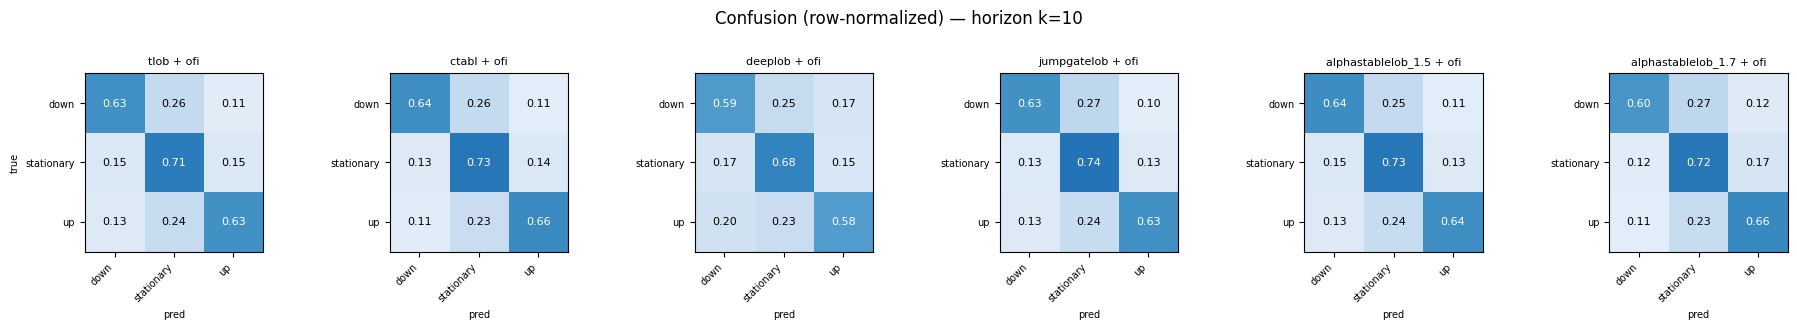

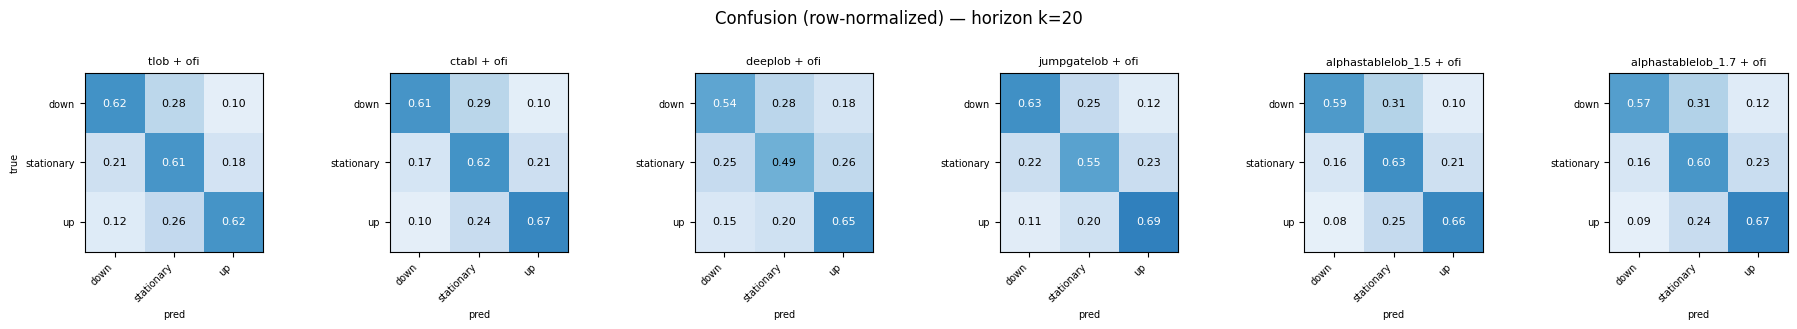

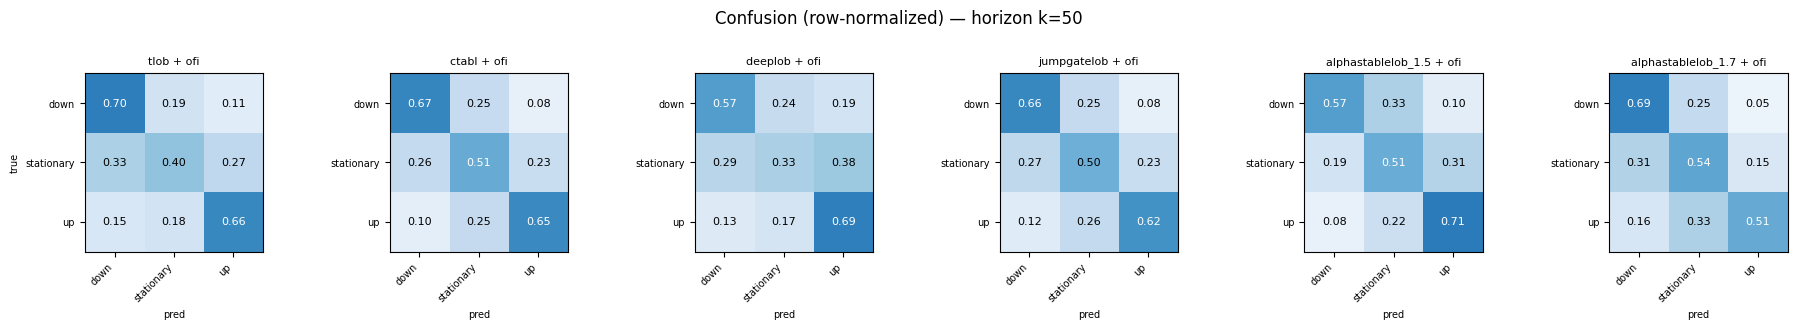

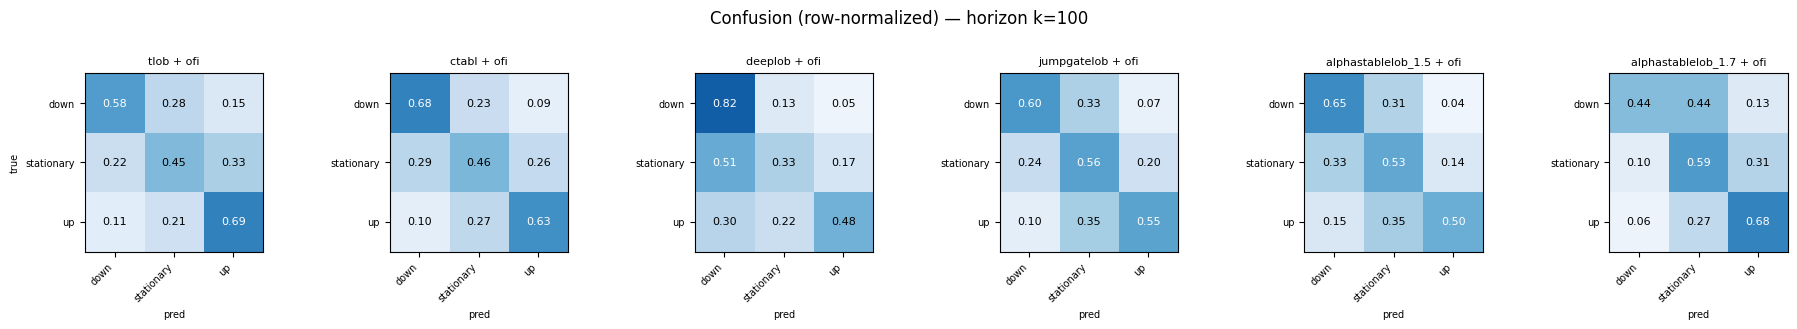

In [7]:
def plot_confusions(k):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    if not tags:
        return
    fig, axes = plt.subplots(
        1, len(tags), figsize=(3.1 * len(tags), 3.0), squeeze=False
    )
    for ax, tag in zip(axes[0], tags):
        r = RESULTS[(tag, k)]
        cm = confusion_matrix(r["y_true"], r["y_pred"], labels=[0, 1, 2]).astype(float)
        cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
        _ = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                ax.text(
                    j,
                    i,
                    f"{cmn[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color="white" if cmn[i, j] > 0.5 else "black",
                    fontsize=8,
                )
        ax.set_xticks(range(3), LABELS, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(3), LABELS, fontsize=7)
        ax.set_title(DISPLAY[tag], fontsize=8)
        ax.set_xlabel("pred", fontsize=7)
    axes[0][0].set_ylabel("true", fontsize=7)
    fig.suptitle(f"Confusion (row-normalized) — horizon k={k}", y=1.04)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_confusions(k)

## 6. Metric vs horizon

How each model's accuracy and macro-F1 evolve as the prediction horizon grows.

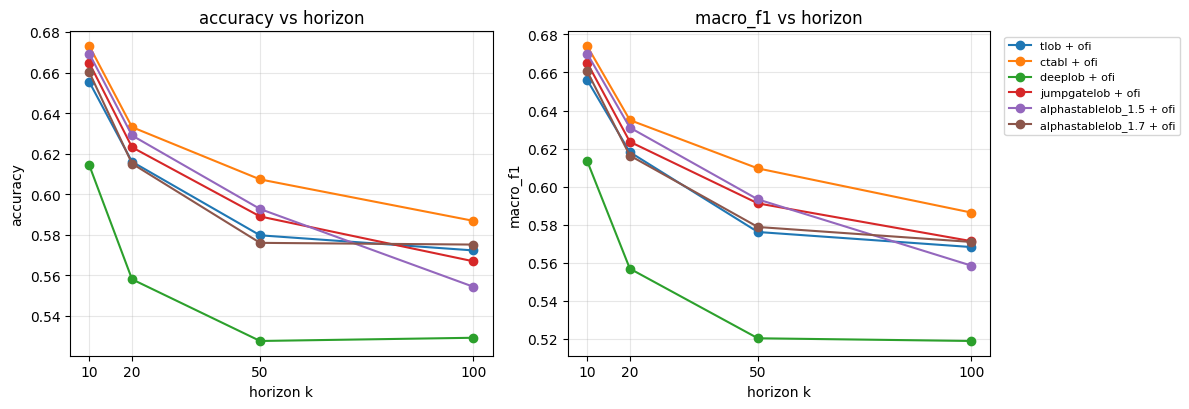

In [8]:
if not metrics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    cmap = plt.get_cmap("tab10")
    present = [m for m in MODELS if DISPLAY[m] in set(metrics_df["model"])]
    for metric, ax in zip(["accuracy", "macro_f1"], axes):
        for i, tag in enumerate(present):
            sub = metrics_df[metrics_df["model"] == DISPLAY[tag]].sort_values("k")
            ax.plot(sub["k"], sub[metric], "o-", color=cmap(i % 10), label=DISPLAY[tag])
        ax.set_xlabel("horizon k")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs horizon")
        ax.set_xticks(HORIZONS)
        ax.grid(alpha=0.3)
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

## 7. Extreme conditions (jumps)

Windows are split by their **stress score** (RV-normalized max increment). We
compare performance on **calm** vs **extreme** windows, where *extreme* = the top
`EXTREME_Q` quantile of stress **within each horizon** (guarantees non-empty
buckets). A large `Δ = calm − extreme` means a model degrades under turbulence;
a small Δ means it is jump-robust.

In [9]:
EXTREME_Q = 0.90  # top 10% most turbulent windows = "extreme"


def split_metrics(r, thr):
    st = r["stress"]
    calm, extr = st <= thr, st > thr
    out = {}
    for name, mask in [("calm", calm), ("extreme", extr)]:
        if mask.sum() == 0:
            out[name] = {"n": 0, "accuracy": np.nan, "macro_f1": np.nan}
            continue
        yt, yp = r["y_true"][mask], r["y_pred"][mask]
        out[name] = {
            "n": int(mask.sum()),
            "accuracy": (yt == yp).mean(),
            "macro_f1": f1_score(
                yt, yp, average="macro", labels=[0, 1, 2], zero_division=0
            ),
        }
    return out


rows = []
for (tag, k), r in RESULTS.items():
    thr = np.quantile(r["stress"], EXTREME_Q)
    s = split_metrics(r, thr)
    rows.append(
        {
            "model": DISPLAY[tag],
            "k": k,
            "acc_calm": s["calm"]["accuracy"],
            "acc_extreme": s["extreme"]["accuracy"],
            "f1_calm": s["calm"]["macro_f1"],
            "f1_extreme": s["extreme"]["macro_f1"],
            "f1_drop": s["calm"]["macro_f1"] - s["extreme"]["macro_f1"],
            "n_extreme": s["extreme"]["n"],
        }
    )
extreme_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
extreme_df

,model,k,acc_calm,acc_extreme,f1_calm,f1_extreme,f1_drop,n_extreme
0,alphastablelob_1.5 + ofi,10,0.6683,0.6772,0.6690,0.6776,-0.0085,2745
1,alphastablelob_1.7 + ofi,10,0.6607,0.6543,0.6614,0.6513,0.0102,2745
2,ctabl + ofi,10,0.6721,0.6816,0.6729,0.6822,-0.0092,2745
3,deeplob + ofi,10,0.6153,0.6033,0.6148,0.6002,0.0145,2745
4,jumpgatelob + ofi,10,0.6629,0.6801,0.6635,0.6799,-0.0165,2745
5,tlob + ofi,10,0.6553,0.6546,0.6562,0.6531,0.0031,2745
6,alphastablelob_1.5 + ofi,20,0.6330,0.5926,0.6354,0.5866,0.0488,2744
7,alphastablelob_1.7 + ofi,20,0.6171,0.5969,0.6186,0.5911,0.0275,2744
8,ctabl + ofi,20,0.6365,0.6024,0.6385,0.6002,0.0383,2744
9,deeplob + ofi,20,0.5593,0.5463,0.5582,0.5409,0.0174,2744


In [10]:
# macro-F1 drop under stress (rows=model, cols=horizon) — lower is more robust
if not extreme_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(extreme_df["model"])]
    piv = extreme_df.pivot(index="model", columns="k", values="f1_drop").reindex(order)
    print("=== macro-F1 drop (calm − extreme); lower = more jump-robust ===")
    display(piv.style.background_gradient(cmap="Reds", axis=None).format("{:.4f}"))

=== macro-F1 drop (calm − extreme); lower = more jump-robust ===


k,10,20,50,100
model,,,,
tlob + ofi,0.0031,0.0303,0.0105,0.0508
ctabl + ofi,-0.0092,0.0383,-0.0105,0.0081
deeplob + ofi,0.0145,0.0174,0.0597,0.0428
jumpgatelob + ofi,-0.0165,0.0253,0.0254,0.0364
alphastablelob_1.5 + ofi,-0.0085,0.0488,0.0084,0.0312
alphastablelob_1.7 + ofi,0.0102,0.0275,0.0133,0.1125


### Accuracy vs stress decile

Windows binned into stress deciles; per-model accuracy in each bin. The right side of each panel is the turbulent regime.

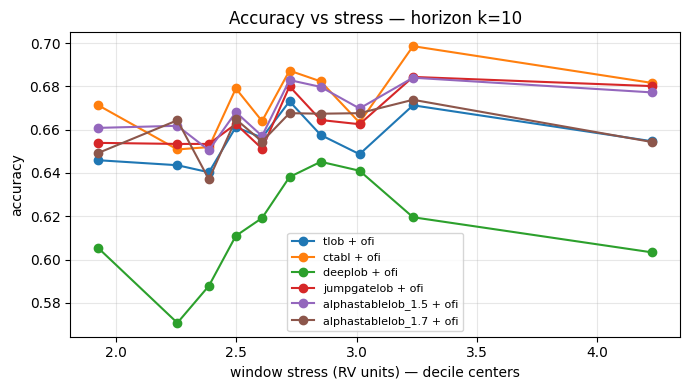

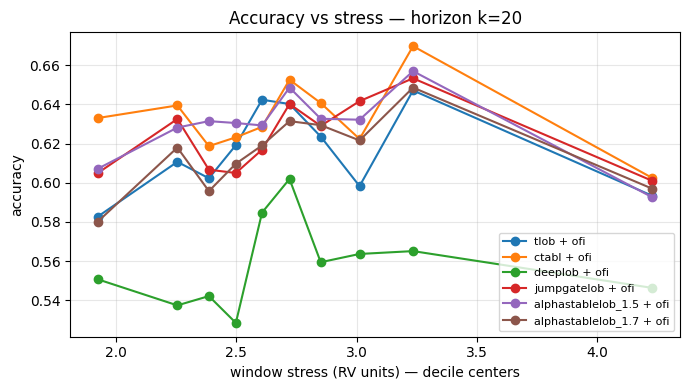

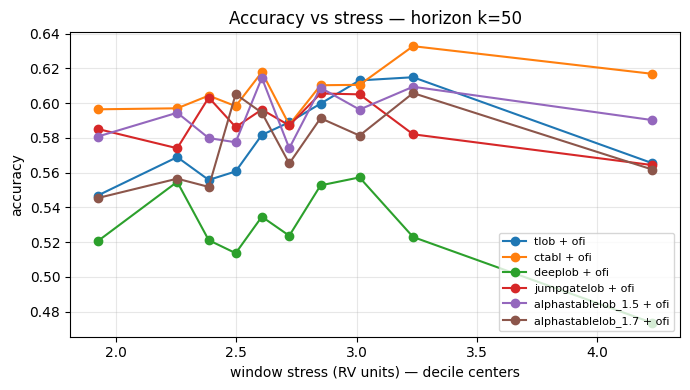

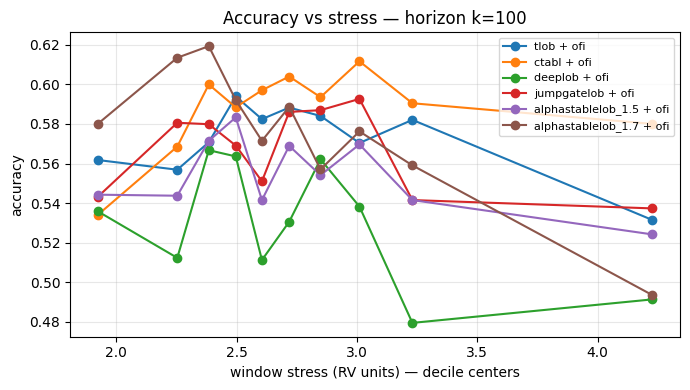

In [11]:
def plot_stress_curves(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    if not tags:
        return None
    stress = RESULTS[(tags[0], k)]["stress"]
    edges = np.quantile(stress, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers = 0.5 * (edges[:-1] + edges[1:])
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, tag in enumerate(tags):
        r = RESULTS[(tag, k)]
        correct = (r["y_true"] == r["y_pred"]).astype(float)
        idx = np.clip(np.digitize(r["stress"], edges) - 1, 0, n_bins - 1)
        acc = [
            correct[idx == b].mean() if (idx == b).any() else np.nan
            for b in range(n_bins)
        ]
        ax.plot(centers, acc, "o-", color=cmap(i % 10), label=DISPLAY[tag])
    ax.set_xlabel("window stress (RV units) — decile centers")
    ax.set_ylabel("accuracy")
    ax.set_title(f"Accuracy vs stress — horizon k={k}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_stress_curves(k)

### Catching the big moves

In the extreme bucket, per-class **recall** for `down` and `up` — does the model still flag large directional moves when they happen?

In [12]:
rows = []
for (tag, k), r in RESULTS.items():
    thr = np.quantile(r["stress"], EXTREME_Q)
    mask = r["stress"] > thr
    if mask.sum() == 0:
        continue
    yt, yp = r["y_true"][mask], r["y_pred"][mask]
    rec = recall_score(yt, yp, average=None, labels=[0, 1, 2], zero_division=0)
    rows.append(
        {"model": DISPLAY[tag], "k": k, "recall_down": rec[0], "recall_up": rec[2]}
    )
recall_df = pd.DataFrame(rows).sort_values(["k", "model"]).reset_index(drop=True)
recall_df

,model,k,recall_down,recall_up
0,alphastablelob_1.5 + ofi,10,0.6020,0.6449
1,alphastablelob_1.7 + ofi,10,0.5022,0.6491
2,ctabl + ofi,10,0.6053,0.6584
3,deeplob + ofi,10,0.5067,0.5642
4,jumpgatelob + ofi,10,0.6098,0.6325
5,tlob + ofi,10,0.5421,0.6263
6,alphastablelob_1.5 + ofi,20,0.4612,0.6314
7,alphastablelob_1.7 + ofi,20,0.4624,0.6811
8,ctabl + ofi,20,0.5138,0.6631
9,deeplob + ofi,20,0.4549,0.6472


## 7b. Financial / trading metrics

Classification scores alone don't say whether signals are *tradeable*. Everything
here is computed against the **realized smoothed trend** `trend_ratio` of each test
window — the exact quantity the ±α labels threshold — so it is a cost-free proxy for
signal quality, **not a trading simulation** (no positions, costs, or fills; that
comes later):

- **MCC & Cohen's κ** — chance-corrected agreement, the headline metrics of recent
  LOB benchmarks (robust to class imbalance, unlike accuracy).
- **Signal rate / directional hit rate** — how often a model calls a direction, and
  the per-signal win rate when it does.
- **Directional capture** — mean signed trend captured per window (bp):
  `+trend` on up-calls, `−trend` on down-calls, `0` on flat.
  `capture_ratio` = captured / oracle (oracle = always right on every window).


In [13]:
def _positions(yp):
    """Predicted position per window: up → +1, down → −1, flat → 0."""
    return np.where(yp == 2, 1, np.where(yp == 0, -1, 0))


fin_rows = []
for (tag, k), r in RESULTS.items():
    m = META.get(k)
    if m is None:
        continue
    yt, yp = r["y_true"], r["y_pred"]
    tr = np.nan_to_num(m["trend"])
    pos = _positions(yp)
    cap = pos * tr
    d = pos != 0
    fin_rows.append(
        {
            "model": DISPLAY[tag],
            "k": k,
            "mcc": matthews_corrcoef(yt, yp),
            "kappa": cohen_kappa_score(yt, yp),
            "signal_rate": d.mean(),
            "hit_rate": (np.sign(tr[d]) == pos[d]).mean() if d.any() else np.nan,
            "capture_bp_win": cap.mean() * 1e4,
            "capture_bp_signal": cap[d].mean() * 1e4 if d.any() else np.nan,
            "oracle_bp_win": np.abs(tr).mean() * 1e4,
            "capture_ratio": cap.mean() / max(np.abs(tr).mean(), 1e-12),
        }
    )
fin_df = pd.DataFrame(fin_rows).sort_values(["k", "model"]).reset_index(drop=True)
fin_df

,model,k,mcc,kappa,signal_rate,hit_rate,capture_bp_win,capture_bp_signal,oracle_bp_win,capture_ratio
0,alphastablelob_1.5 + ofi,10,0.5066,0.5037,0.5945,0.8157,2.3340,3.9258,3.7203,0.6274
1,alphastablelob_1.7 + ofi,10,0.4932,0.4898,0.5901,0.8101,2.3169,3.9261,3.7203,0.6228
2,ctabl + ofi,10,0.5122,0.5094,0.5954,0.8216,2.3715,3.9828,3.7203,0.6374
3,deeplob + ofi,10,0.4224,0.4211,0.6156,0.7315,1.9096,3.1020,3.7203,0.5133
4,jumpgatelob + ofi,10,0.5009,0.4968,0.5807,0.8114,2.3049,3.9692,3.7203,0.6196
5,tlob + ofi,10,0.4853,0.4828,0.5973,0.8063,2.3136,3.8734,3.7203,0.6219
6,alphastablelob_1.5 + ofi,20,0.4433,0.4416,0.5972,0.8207,3.2931,5.5140,5.2050,0.6327
7,alphastablelob_1.7 + ofi,20,0.4221,0.4207,0.6107,0.8006,3.2230,5.2775,5.2050,0.6192
8,ctabl + ofi,20,0.4490,0.4482,0.6152,0.8189,3.3275,5.4087,5.2050,0.6393
9,deeplob + ofi,20,0.3368,0.3364,0.6720,0.7323,2.7790,4.1351,5.2050,0.5339


In [14]:
# MCC and capture-ratio pivots (rows = model, cols = horizon)
if not fin_df.empty:
    order = [DISPLAY[m] for m in MODELS if DISPLAY[m] in set(fin_df["model"])]
    for metric in ["mcc", "capture_ratio", "hit_rate"]:
        piv = fin_df.pivot(index="model", columns="k", values=metric).reindex(order)
        print(f"\n=== {metric} (rows=model, cols=horizon k) ===")
        display(piv.style.background_gradient(cmap="YlGn", axis=None).format("{:.4f}"))


=== mcc (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
tlob + ofi,0.4853,0.4239,0.3773,0.3555
ctabl + ofi,0.5122,0.4490,0.4108,0.3807
deeplob + ofi,0.4224,0.3368,0.2971,0.3234
jumpgatelob + ofi,0.5009,0.4343,0.3840,0.3523
alphastablelob_1.5 + ofi,0.5066,0.4433,0.3869,0.3400
alphastablelob_1.7 + ofi,0.4932,0.4221,0.3686,0.3607



=== capture_ratio (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
tlob + ofi,0.6219,0.6100,0.6132,0.5772
ctabl + ofi,0.6374,0.6393,0.6345,0.6068
deeplob + ofi,0.5133,0.5339,0.5348,0.4929
jumpgatelob + ofi,0.6196,0.6414,0.6007,0.5430
alphastablelob_1.5 + ofi,0.6274,0.6327,0.6181,0.5126
alphastablelob_1.7 + ofi,0.6228,0.6192,0.5572,0.5461



=== hit_rate (rows=model, cols=horizon k) ===


k,10,20,50,100
model,,,,
tlob + ofi,0.8063,0.7998,0.7674,0.7776
ctabl + ofi,0.8216,0.8189,0.8232,0.8099
deeplob + ofi,0.7315,0.7323,0.7430,0.7315
jumpgatelob + ofi,0.8114,0.8020,0.7989,0.8092
alphastablelob_1.5 + ofi,0.8157,0.8207,0.8149,0.7941
alphastablelob_1.7 + ofi,0.8101,0.8006,0.7802,0.8066


### Mid-price path vs model predictions

The mid-price over the most active stretch of the test period, with **true**
up/down regimes shaded (green = up, red = down, white = flat). Each strip below is
one model's predicted label over the same windows — you can see directly *where*
each model catches or misses the moves. Change `seg_len`/`start` to zoom.


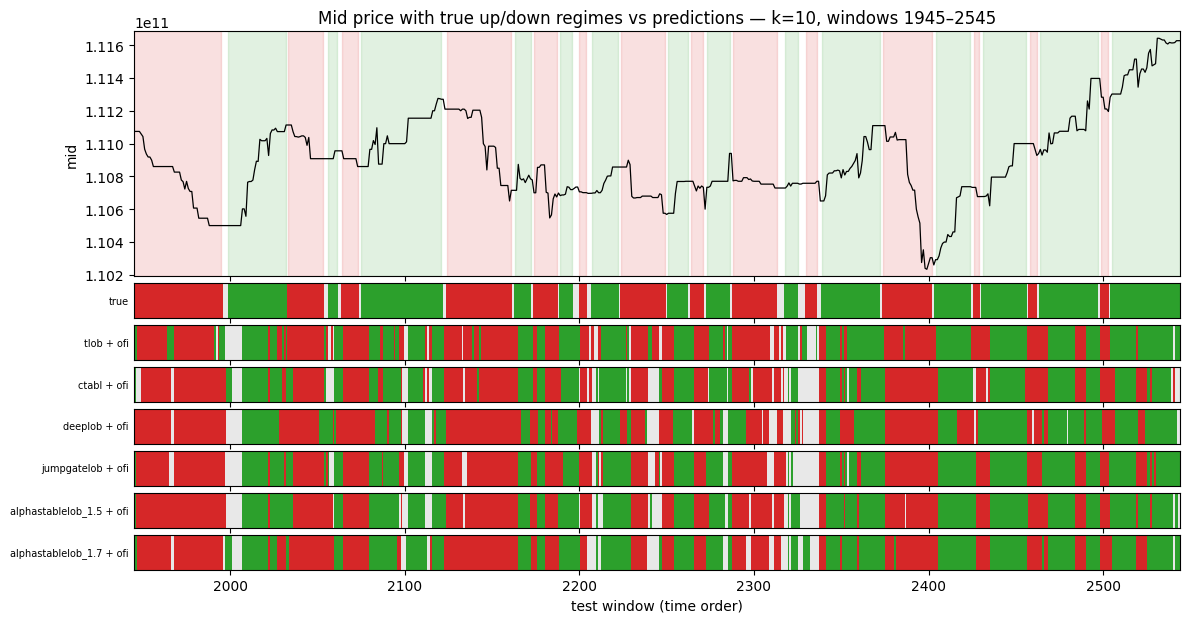

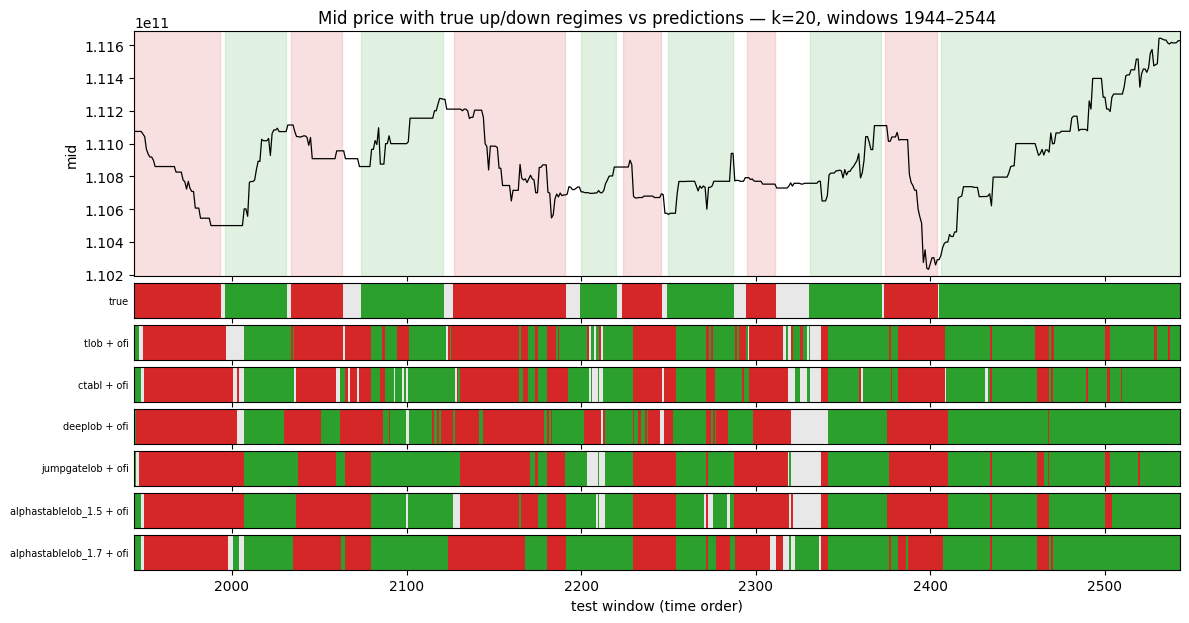

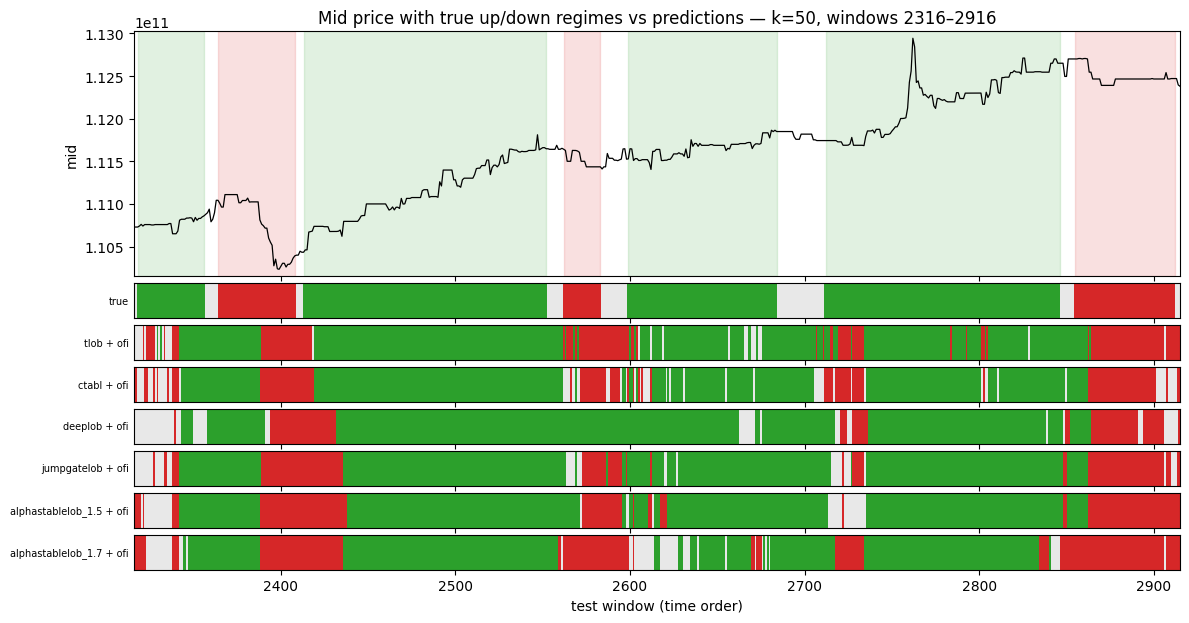

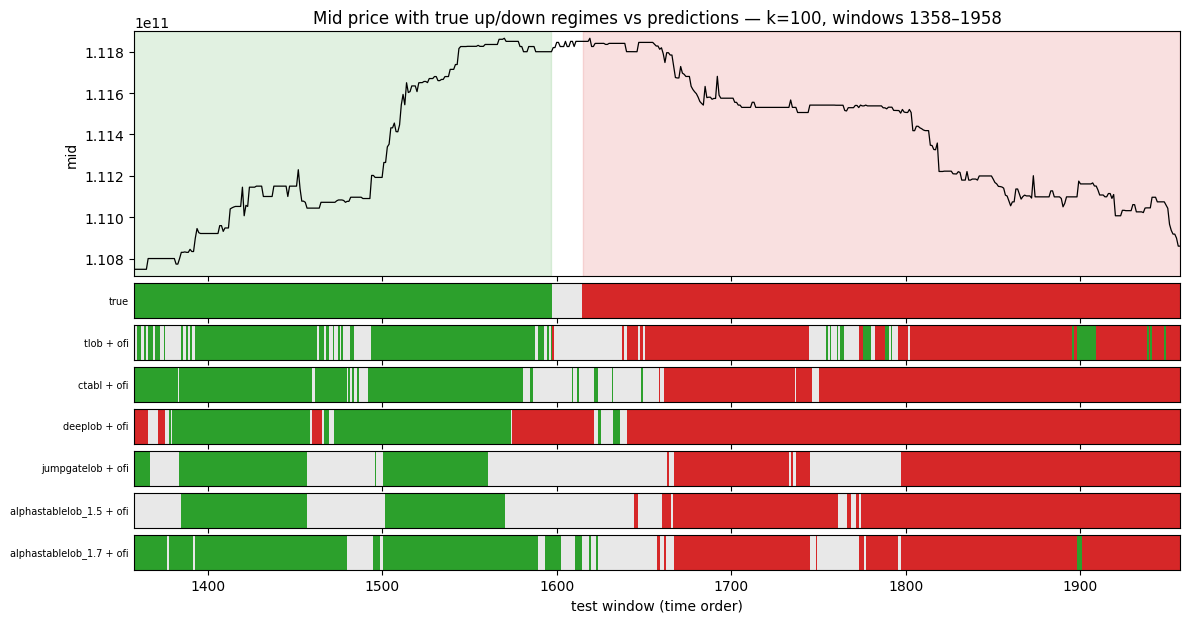

In [15]:
LAB_CMAP = ListedColormap(["#d62728", "#e8e8e8", "#2ca02c"])  # down / flat / up


def plot_price_predictions(k, seg_len=600, start=None):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    y_true = RESULTS[(tags[0], k)]["y_true"]
    tr = np.nan_to_num(m["trend"])
    seg_len = min(seg_len, len(y_true))
    if start is None:  # auto-pick the stretch with the most |trend| mass
        act = np.convolve(np.abs(tr), np.ones(seg_len), "valid")
        start = int(act.argmax())
    sl = slice(start, start + seg_len)
    idx = np.arange(start, start + seg_len)
    price = m["mid"][m["centres"][sl]]
    yt_seg = y_true[sl]

    lanes = [("true", yt_seg)] + [
        (DISPLAY[t], RESULTS[(t, k)]["y_pred"][sl]) for t in tags
    ]
    fig, axes = plt.subplots(
        1 + len(lanes),
        1,
        figsize=(12, 3.4 + 0.42 * len(lanes)),
        sharex=True,
        gridspec_kw={"height_ratios": [7] + [1] * len(lanes)},
    )
    ax = axes[0]
    ax.plot(idx, price, lw=0.9, color="black")
    lo, hi = price.min(), price.max()
    pad = 0.03 * (hi - lo + 1e-9)
    ax.fill_between(
        idx,
        lo - pad,
        hi + pad,
        where=yt_seg == 2,
        color="#2ca02c",
        alpha=0.14,
        step="mid",
    )
    ax.fill_between(
        idx,
        lo - pad,
        hi + pad,
        where=yt_seg == 0,
        color="#d62728",
        alpha=0.14,
        step="mid",
    )
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_ylabel("mid")
    ax.set_title(
        f"Mid price with true up/down regimes vs predictions — "
        f"k={k}, windows {start}–{start + seg_len}"
    )
    for axl, (name, lab) in zip(axes[1:], lanes):
        axl.imshow(
            lab[None, :],
            aspect="auto",
            cmap=LAB_CMAP,
            vmin=0,
            vmax=2,
            extent=[idx[0], idx[-1], 0, 1],
            interpolation="nearest",
        )
        axl.set_yticks([])
        axl.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=7)
    axes[-1].set_xlabel("test window (time order)")
    fig.tight_layout(h_pad=0.15)
    plt.show()


for k in HORIZONS:
    plot_price_predictions(k)

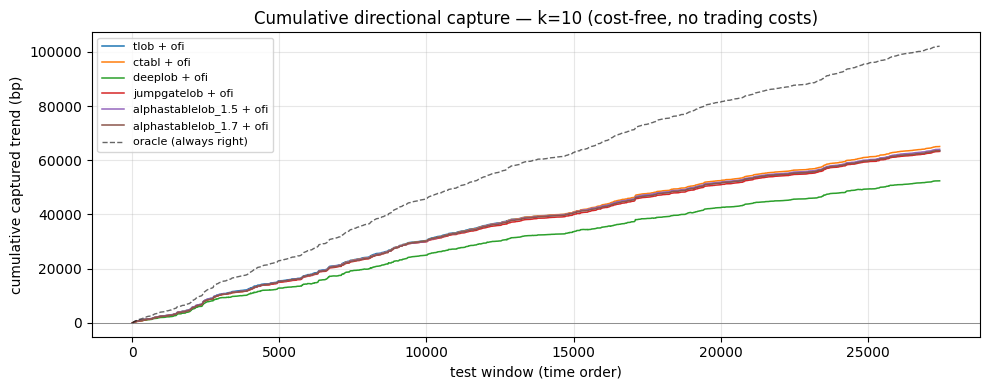

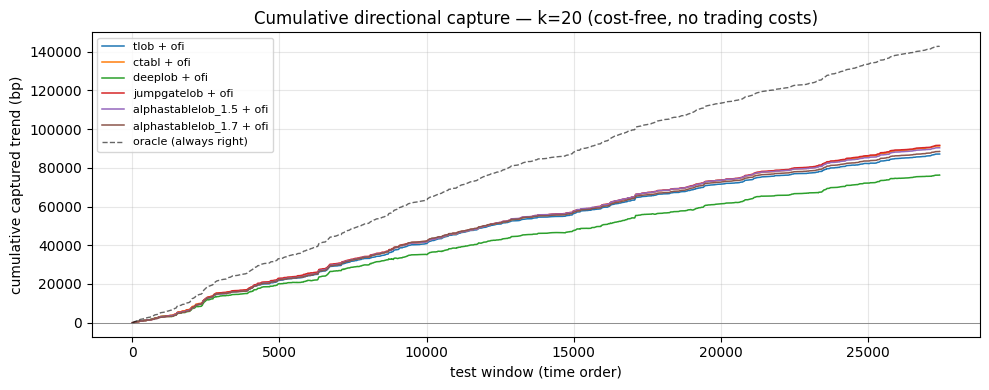

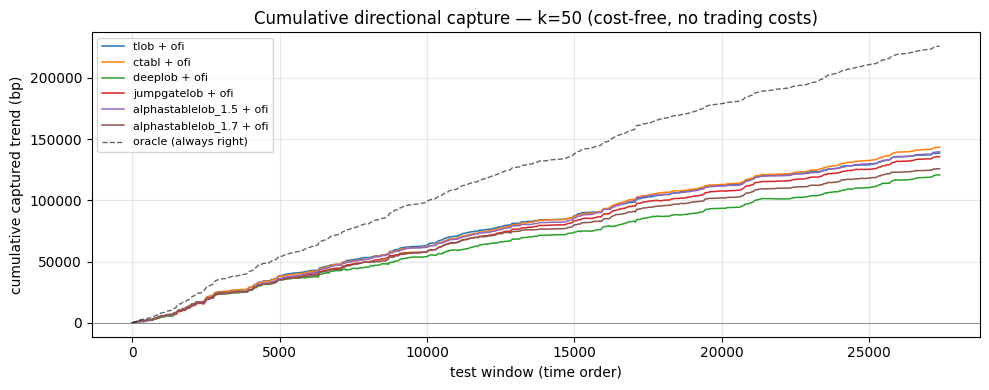

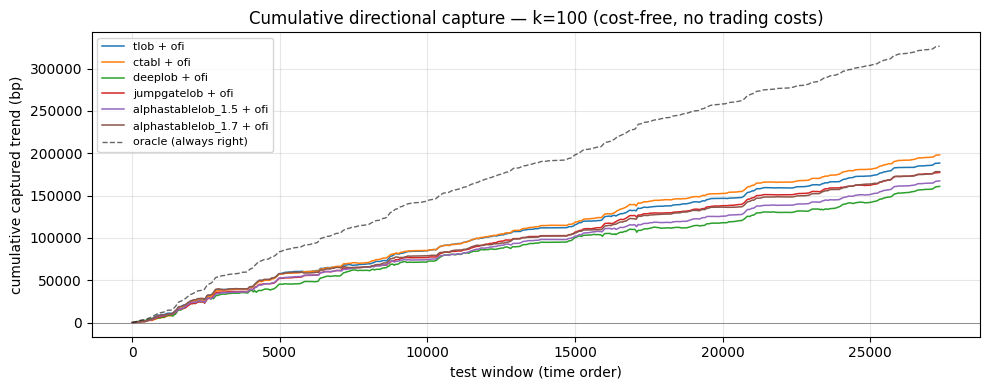

In [16]:
def plot_capture(k):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    tr = np.nan_to_num(m["trend"])
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, tag in enumerate(tags):
        cap = _positions(RESULTS[(tag, k)]["y_pred"]) * tr
        ax.plot(np.cumsum(cap) * 1e4, color=cmap(i % 10), lw=1.1, label=DISPLAY[tag])
    ax.plot(
        np.cumsum(np.abs(tr)) * 1e4,
        "k--",
        lw=1.0,
        alpha=0.6,
        label="oracle (always right)",
    )
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlabel("test window (time order)")
    ax.set_ylabel("cumulative captured trend (bp)")
    ax.set_title(
        f"Cumulative directional capture — k={k} (cost-free, no trading costs)"
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_capture(k)

### Calibration & confidence gating

Left — reliability: mean accuracy per confidence decile vs the diagonal (a
calibrated model can be *sized* by its probability). Middle/right — trade only when
`p_max ≥ τ` **and** the call is directional: per-signal hit rate and capture (bp) as
the confidence gate tightens. A model whose hit rate and capture rise with τ gives a
usable filter for the later trading simulation.


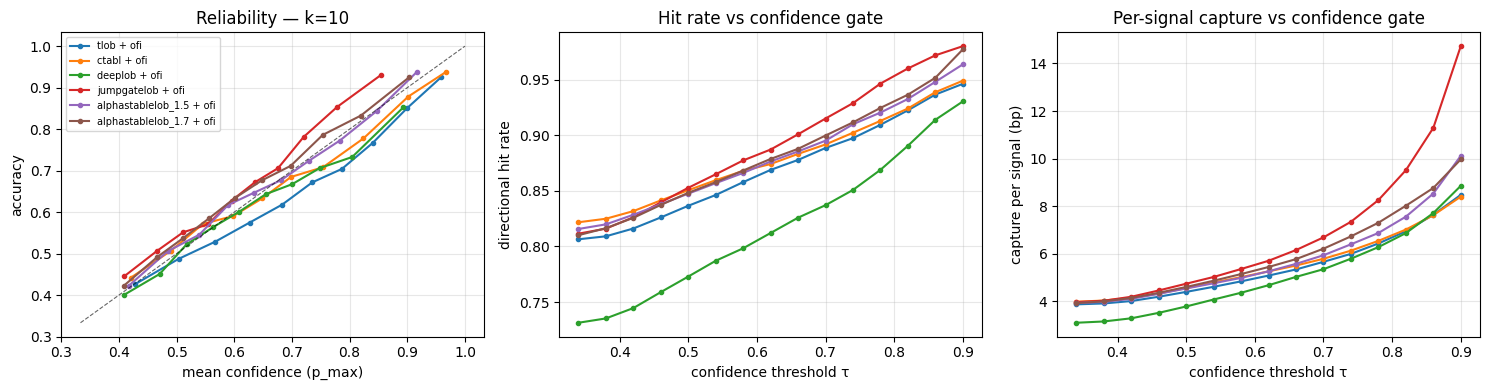

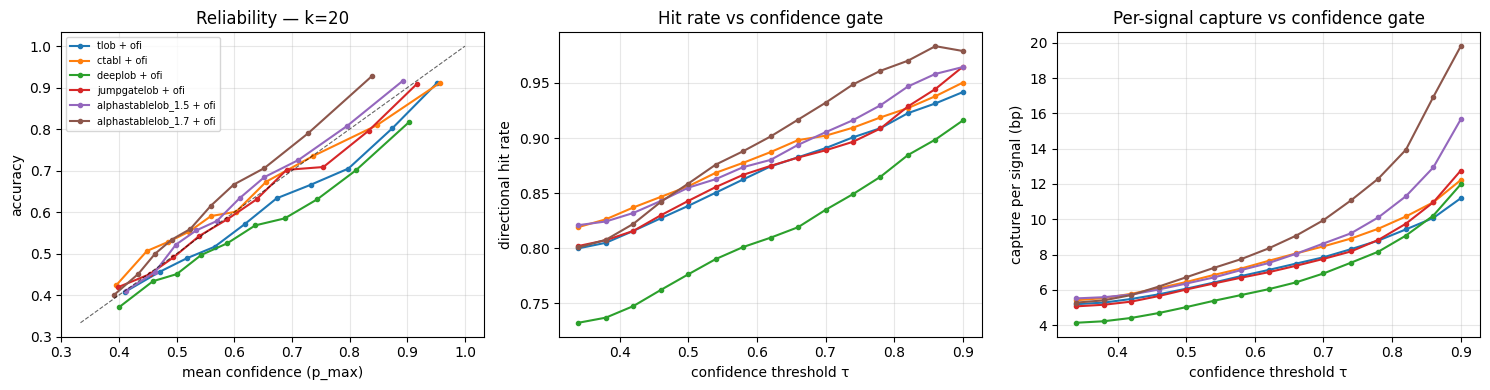

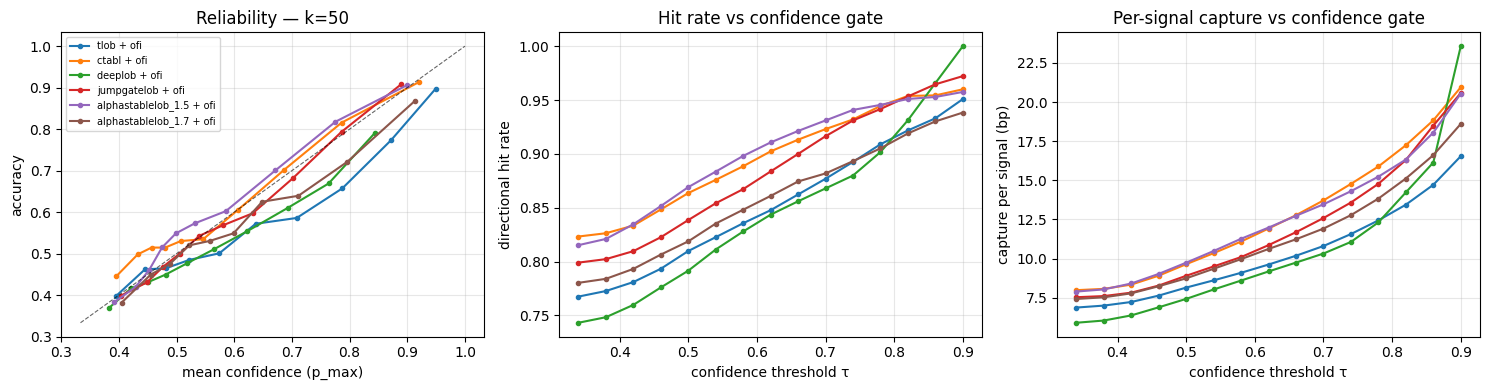

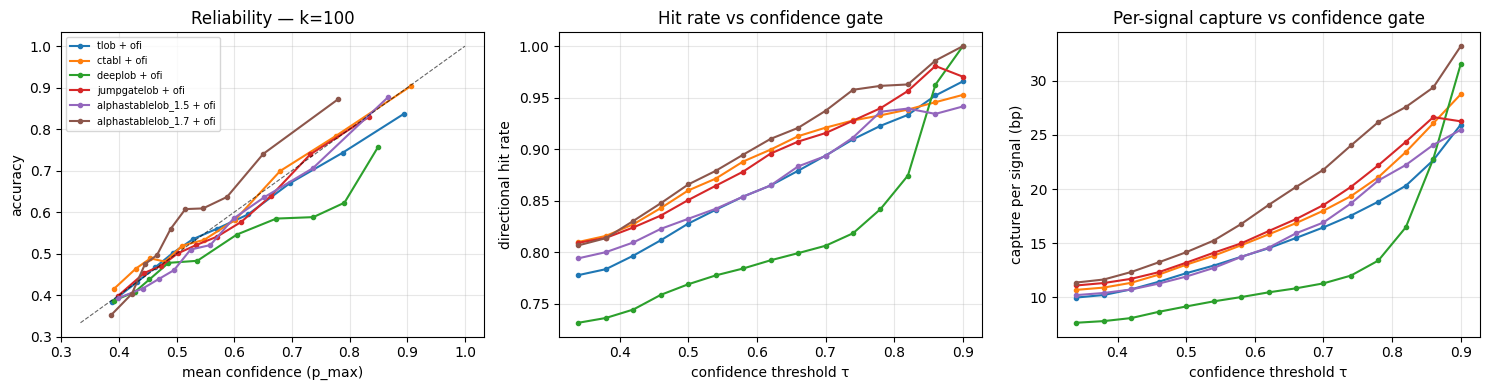

In [17]:
def plot_calibration_gating(k, n_bins=10):
    tags = [t for t in MODELS if (t, k) in RESULTS]
    m = META.get(k)
    if not tags or m is None:
        return
    tr = np.nan_to_num(m["trend"])
    taus = np.linspace(0.34, 0.90, 15)
    cmap = plt.get_cmap("tab10")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, tag in enumerate(tags):
        r = RESULTS[(tag, k)]
        conf = r["probs"].max(1)
        correct = (r["y_true"] == r["y_pred"]).astype(float)
        edges = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
        edges[-1] += 1e-9
        bi = np.clip(np.digitize(conf, edges) - 1, 0, n_bins - 1)
        xs = [
            conf[bi == b].mean() if (bi == b).any() else np.nan for b in range(n_bins)
        ]
        ys = [
            correct[bi == b].mean() if (bi == b).any() else np.nan
            for b in range(n_bins)
        ]
        axes[0].plot(xs, ys, "o-", ms=3, color=cmap(i % 10), label=DISPLAY[tag])
        pos = _positions(r["y_pred"])
        hit, cap = [], []
        for tau in taus:
            sel = (pos != 0) & (conf >= tau)
            hit.append((np.sign(tr[sel]) == pos[sel]).mean() if sel.any() else np.nan)
            cap.append((pos[sel] * tr[sel]).mean() * 1e4 if sel.any() else np.nan)
        axes[1].plot(taus, hit, "o-", ms=3, color=cmap(i % 10))
        axes[2].plot(taus, cap, "o-", ms=3, color=cmap(i % 10))
    axes[0].plot([1 / 3, 1], [1 / 3, 1], "k--", lw=0.8, alpha=0.6)
    axes[0].set_xlabel("mean confidence (p_max)")
    axes[0].set_ylabel("accuracy")
    axes[0].set_title(f"Reliability — k={k}")
    axes[0].legend(fontsize=7)
    axes[1].set_xlabel("confidence threshold τ")
    axes[1].set_ylabel("directional hit rate")
    axes[1].set_title("Hit rate vs confidence gate")
    axes[2].set_xlabel("confidence threshold τ")
    axes[2].set_ylabel("capture per signal (bp)")
    axes[2].set_title("Per-signal capture vs confidence gate")
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


for k in HORIZONS:
    plot_calibration_gating(k)

## 8. Final model comparison table

Mean macro-F1 across horizons (overall, calm, extreme) plus the financial
aggregates (mean MCC / capture ratio). `robustness` = extreme / calm.


In [18]:
if RESULTS:
    agg = metrics_df.groupby("model")["macro_f1"].mean().rename("macro_f1_mean")
    parts = [agg]
    if not fin_df.empty:
        parts.append(fin_df.groupby("model")[["mcc", "capture_ratio"]].mean())
    ex = extreme_df.groupby("model")[["f1_calm", "f1_extreme"]].mean()
    parts.append(ex)
    summary = pd.concat(parts, axis=1)
    summary["robustness"] = summary["f1_extreme"] / summary["f1_calm"].clip(lower=1e-9)
    summary = summary.sort_values("macro_f1_mean", ascending=False)
    grad_cols = [
        c
        for c in ["macro_f1_mean", "mcc", "capture_ratio", "f1_calm", "f1_extreme"]
        if c in summary.columns
    ]
    display(
        summary.style.background_gradient(cmap="YlGn", subset=grad_cols).format(
            "{:.4f}"
        )
    )
else:
    print("No results — populate CHECKPOINTS in section 2 and re-run.")

,macro_f1_mean,mcc,capture_ratio,f1_calm,f1_extreme,robustness
model,,,,,,
ctabl + ofi,0.6262,0.4382,0.6295,0.6267,0.6201,0.9893
alphastablelob_1.5 + ofi,0.6132,0.4192,0.5977,0.6149,0.5950,0.9676
jumpgatelob + ofi,0.6128,0.4179,0.6012,0.6144,0.5968,0.9713
alphastablelob_1.7 + ofi,0.6066,0.4111,0.5863,0.6103,0.5694,0.9330
tlob + ofi,0.6046,0.4105,0.6056,0.6065,0.5829,0.9610
deeplob + ofi,0.5523,0.3449,0.5187,0.5553,0.5217,0.9395
